## Persistent Homology to detect endotypes

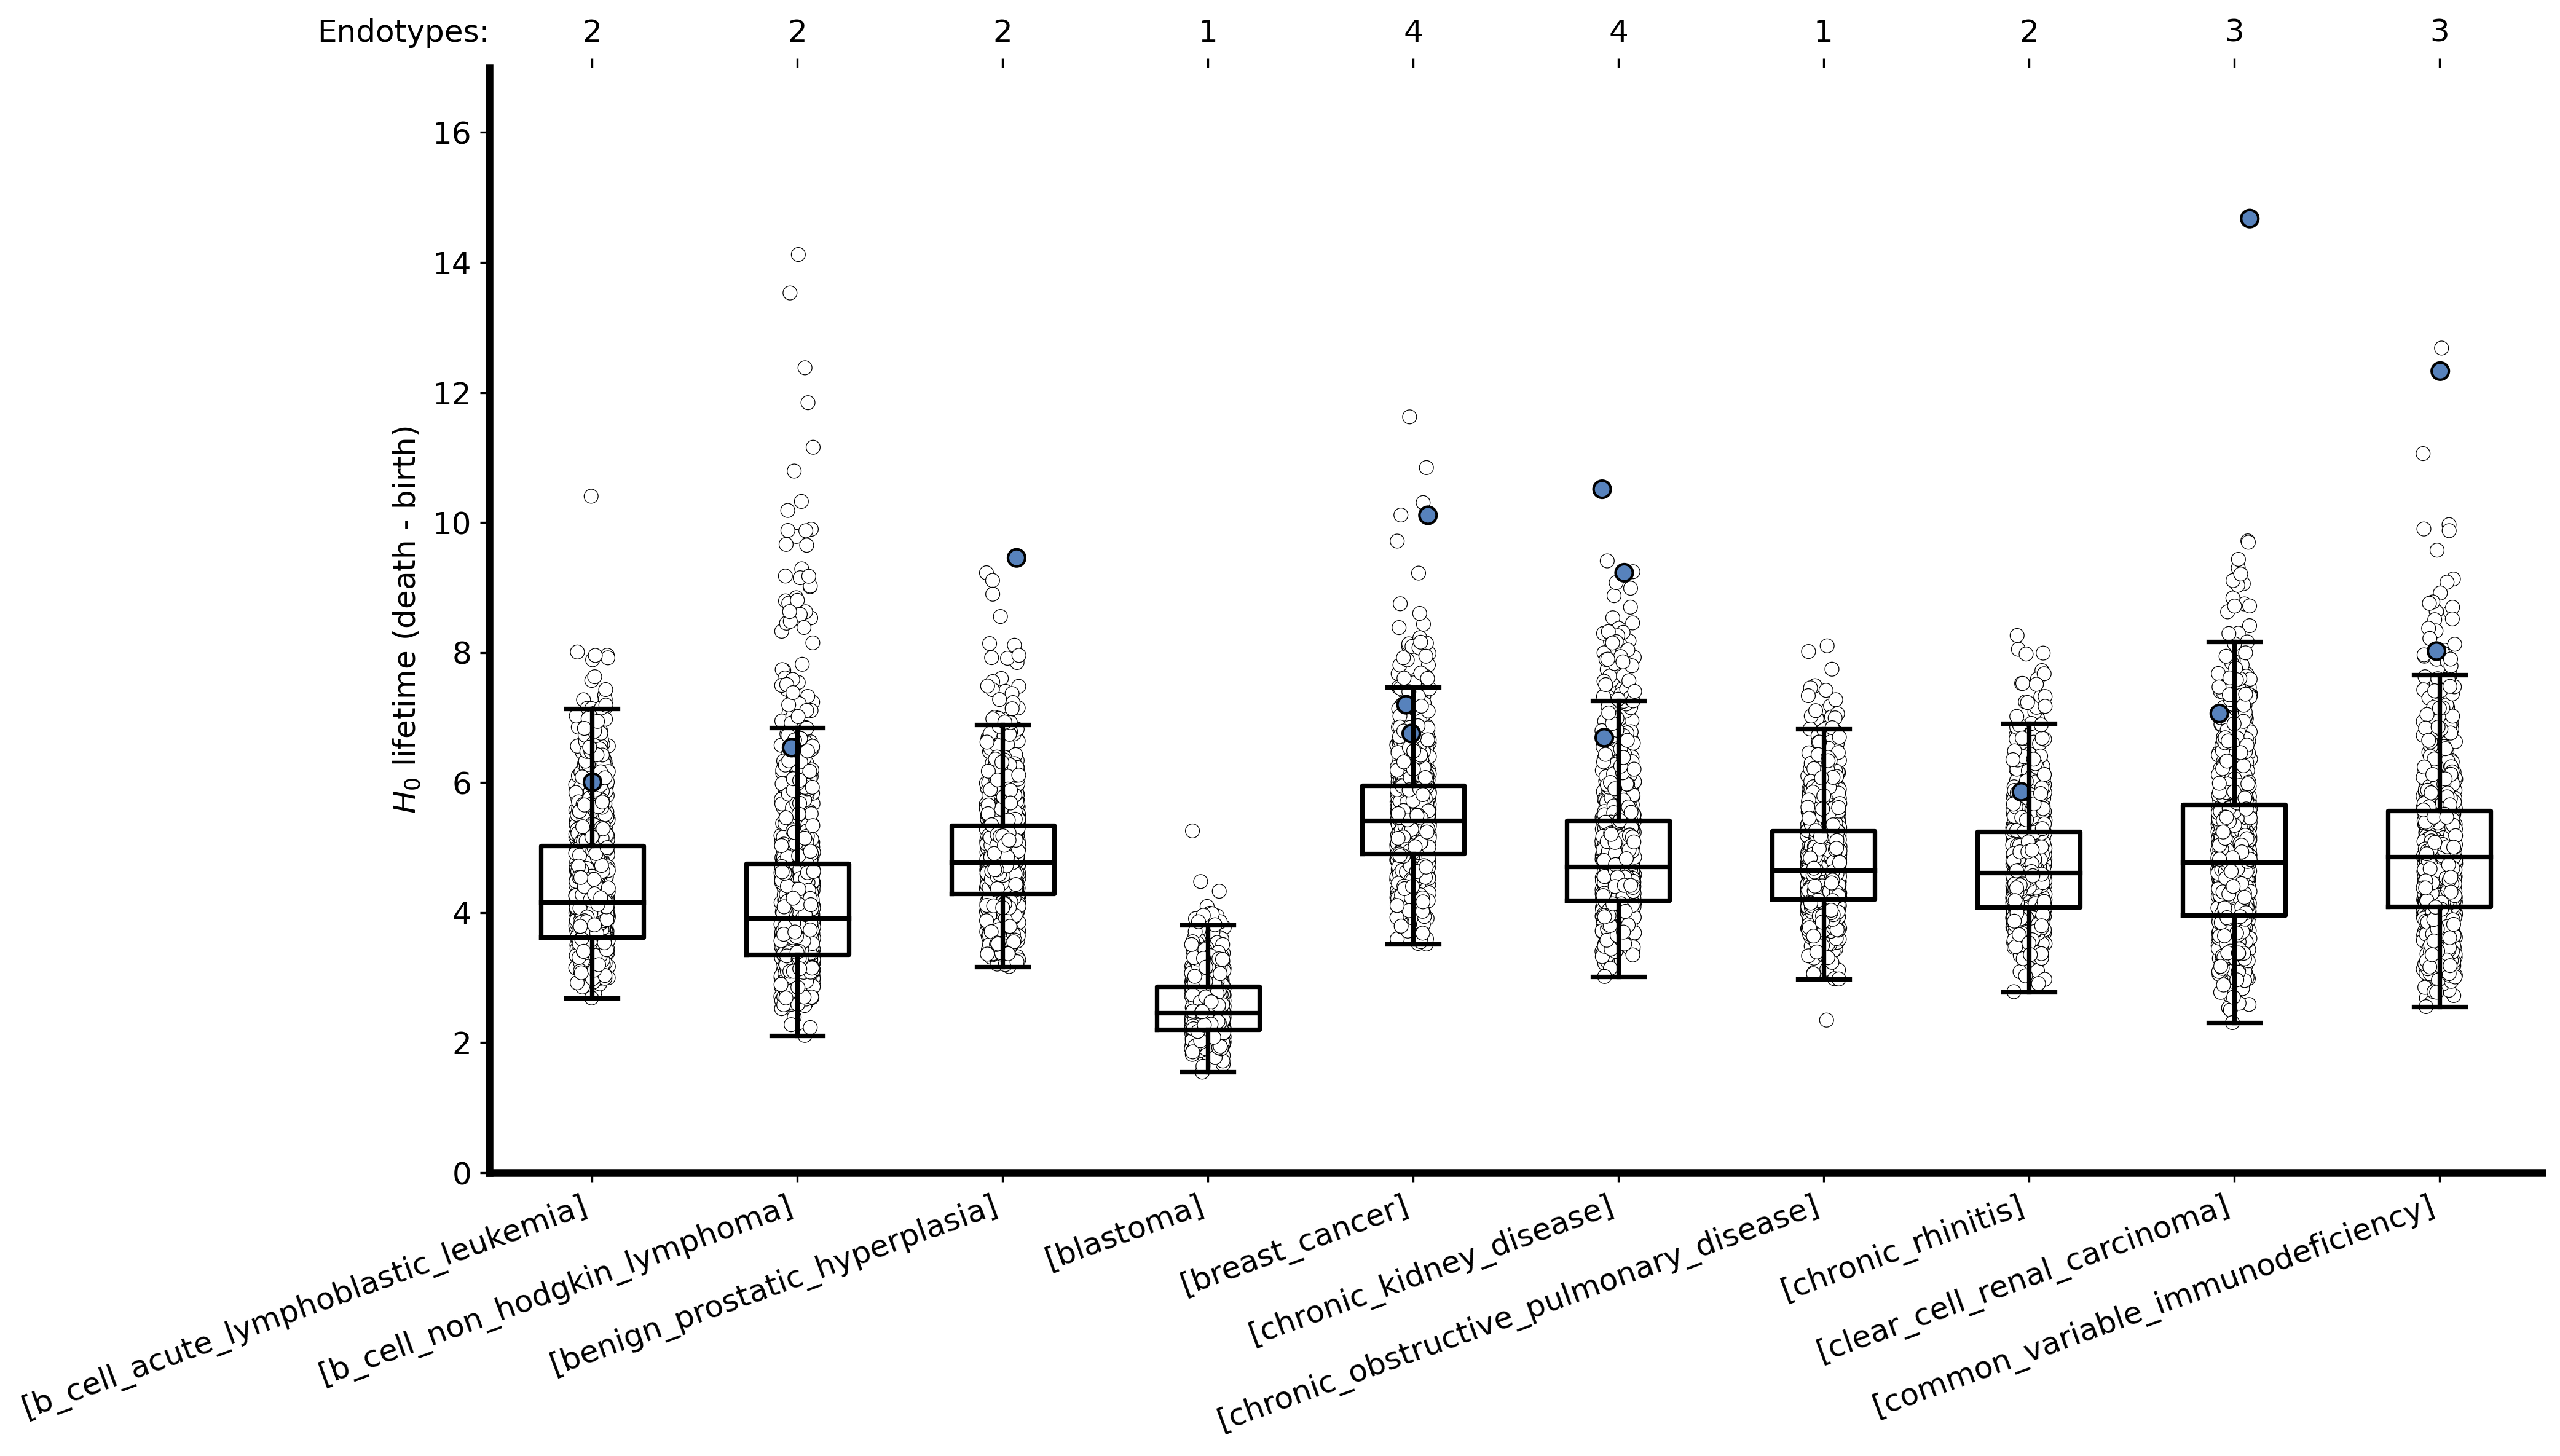

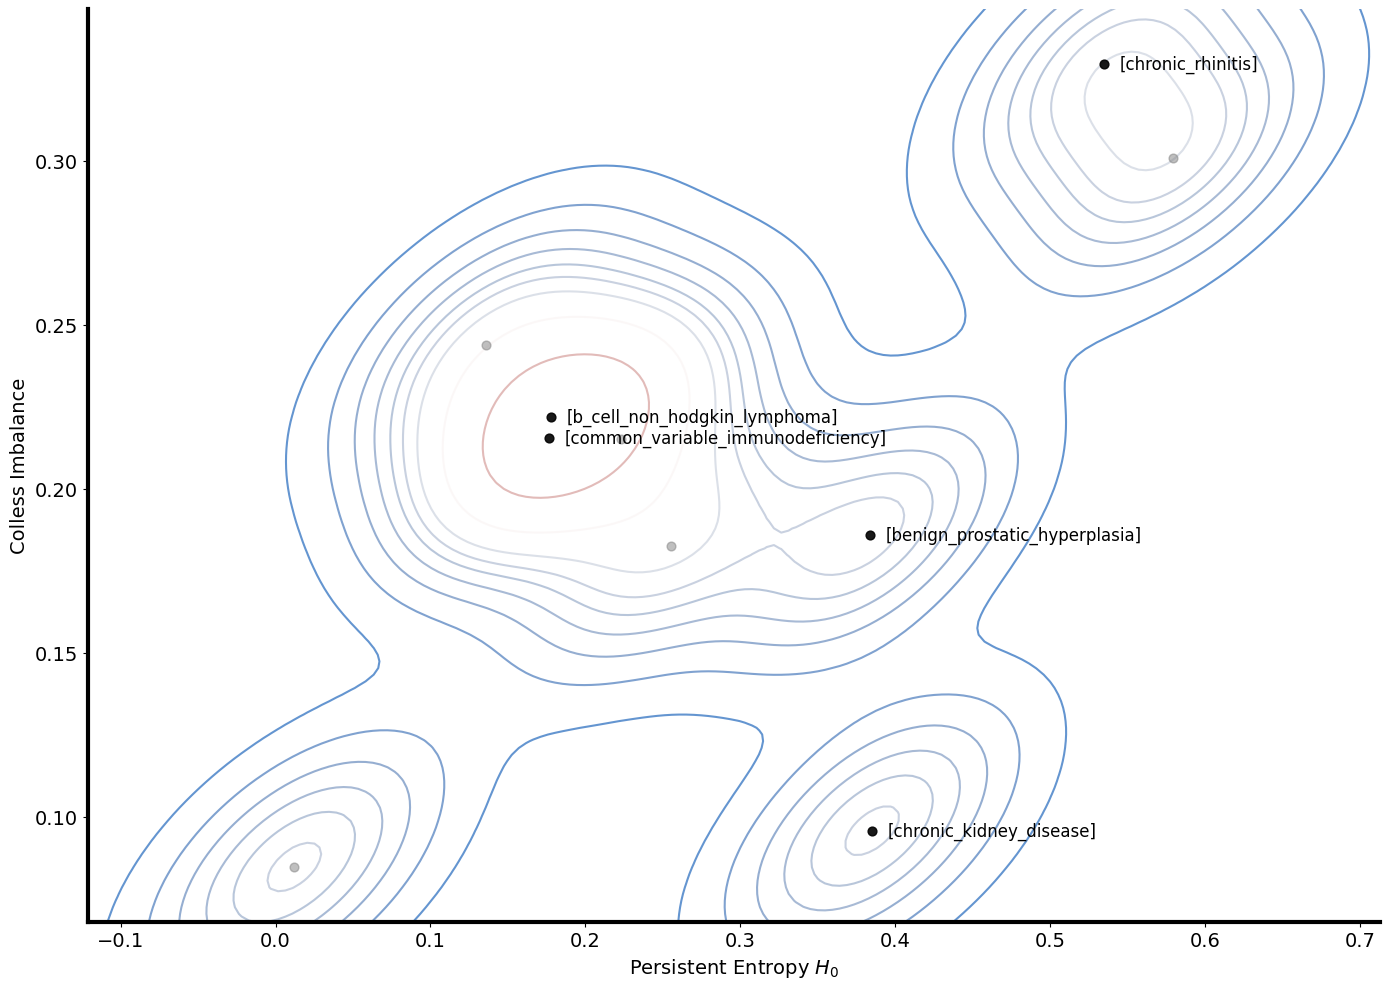

In [10]:
# plotting suite
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns

EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/'
SAVE = False
boxplots_path = ""
colless_entropy_path = ""

def plot_h0_boxplots_with_jitter(result_df, max_diseases=10, jitter=0.08, alpha=0.6, point_size=20, color_dict=None, fontsize=14, show=True, save=False, save_path="", figsize=(12,6), cmap="Paired"):
    diseases = result_df.columns.tolist()[:max_diseases]
    if color_dict is None: 
        cmap = ['white']*len(diseases)#sns.color_palette(cmap, len(persistence_dict))
        color_dict = {d: cmap[i] for i, d in enumerate(diseases )}
    labels, data, mask = diseases, [np.clip(lifetimes, None, 18)#np.nanmax(lifetimes[np.isfinite(lifetimes)]))
                                     for lifetimes in result_df.loc["h0", diseases].tolist()], result_df.loc["h0_significance", diseases].tolist() 
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    box_color = 'k'
    median_color = 'k'
    box_linewidth = 1.75
    bp = ax.boxplot(data, labels=labels, showfliers=False,zorder=4, boxprops=dict(color=box_color, linewidth=box_linewidth),
                    whiskerprops=dict(color=box_color, linewidth=box_linewidth),
                    capprops=dict(color=box_color, linewidth=box_linewidth),
                    medianprops=dict(color=median_color, linewidth=box_linewidth, zorder=3),)

    endotype_counts = []
    for i, (label, lifetimes, mask_out) in enumerate(zip(labels, data, mask), start=1):
        mask_in = ~mask_out & (lifetimes > 0)
        endotype_counts.append(mask_out.sum())
        xin = i + np.random.uniform(-jitter, jitter, size=mask_in.sum())
        xout = i + np.random.uniform(-jitter, jitter, size=mask_out.sum())

        ax.scatter(xin, lifetimes[mask_in], s=point_size, alpha=alpha, linewidths=.3, edgecolor='k',
                   c=[color_dict[labels[i-1]]] * mask_in.sum())
        color = sns.color_palette("vlag", len(diseases))[0]
        ax.scatter(xout, lifetimes[mask_out], s=int(point_size*1.5), alpha=1, c=[color]*mask_out.sum(), label="Outliers = Endotypes" if i == 1 else None, linewidths=1, edgecolor='k',)
        #if show: print("Endotype thresholds", labels[i-1], ":", np.round(persistence_threshold, 2), size_threshold)
    plt.ylim(0, max(np.concatenate(data))-1)

    ax.text(0.5, ax.get_ylim()[1] + 0.3, f"Endotypes:", ha="right", va="bottom", fontsize=fontsize)
    for i, ecnt in enumerate(endotype_counts, start=1):
        ax.text(i, ax.get_ylim()[1] + 0.3, f"{ecnt}", ha="center", va="bottom", fontsize=fontsize)
    ax.set_ylabel("$H_0$ lifetime (death - birth)", fontsize=fontsize)
    #ax.set_title("Connected components ($H_0$) persistence (lifetime) per disease", y=1.08, fontsize=fontsize)
    ax.tick_params(axis="x", which="both", top=True, labeltop=False)
    plt.xticks(rotation=20, ha='right', fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    #plt.legend(fontsize=fontsize)#, lw=2)
    [ax.spines[s].set_linewidth(0) for s in ['right','top']]
    [ax.spines[s].set_linewidth(3) for s in ['bottom','left']]
    plt.tight_layout()
    if SAVE: plt.savefig(boxplots_path, dpi=300, transparent=True)
    if show: plt.show()
    else: plt.close()


df = pd.DataFrame(pd.read_pickle(EMBEDDINGS_DIR + "endotype_results.pkl"))
disease_selection = ('Renal','Gastr','Carcinoma','Park','Dementia','Alz','Norm','Plasma','carcino')
df_sel = df[[k for k in df.columns ]]#if any(s in k for s in disease_selection)]]
plot_h0_boxplots_with_jitter(df_sel, max_diseases=20, figsize=(14,8), alpha=1, jitter=0.08, point_size=30, fontsize=12
                                                            ,show=True, cmap="Spectral", save_path='disease-vector-plots/figure3/')

import random
plt.figure(figsize=(14,10), dpi=300 if SAVE else 100)
size = 12
#annotated = metrics_df[(metrics_df['colless'] < .05) ]['disease']
metrics_df = pd.DataFrame({"disease": df.columns, "colless": df.loc['colless',:].tolist(),  "entropy": df.loc['entropy',:].tolist()})
#annotated = metrics_df[metrics_df.disease.str.contains('Renal|Gastr|Carcinoma|Park|Dementia|Alz|Norm|Plasma|carcino', regex=True)].disease.tolist()
annotated = set(random.sample(list(metrics_df["disease"]), 5))
df_ann = metrics_df[metrics_df["disease"].isin(annotated)]
df_rest = metrics_df[~metrics_df["disease"].isin(annotated)]

sns.kdeplot(x=metrics_df["entropy"], y=metrics_df["colless"], levels=10, fill=False, cmap="vlag", alpha=0.7, zorder=-10, bw_adjust=0.5, linewidths=1.5)
plt.scatter(df_rest["entropy"], df_rest["colless"], s=40, alpha=0.5, color="grey")
color = "k"#sns.color_palette('Paired', len(df_ann))
plt.scatter(df_ann["entropy"], df_ann["colless"], s=40, alpha=0.9, color=color, zorder=10)

ax = plt.gca()
x_unit, y_unit = np.diff(ax.get_xticks())[0], np.diff(ax.get_yticks())[0]
for _, row in df_ann.iterrows():
    plt.annotate(row["disease"], (row["entropy"]+x_unit/20, row["colless"]), fontsize=size, alpha=1, va="center", ha="left", fontweight='500')

dividerx, dividery = 1.5, 3
xlim, ylim = (metrics_df["entropy"].min()-x_unit/dividerx, metrics_df["entropy"].max()+x_unit/dividerx), (metrics_df["colless"].min()-y_unit/dividery, metrics_df["colless"].max()+y_unit/dividery)
plt.xlim(xlim); plt.ylim(ylim)
plt.xlabel("Persistent Entropy $H_0$", fontsize=14)
plt.ylabel("Colless Imbalance", fontsize=14)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.gca().spines['left'].set_linewidth(3)
plt.gca().spines['bottom'].set_linewidth(3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

if SAVE: plt.savefig(colless_entropy_path, dpi=300, transparent=True)
plt.show()


N components: 2 Filtration epsilon: 1.5


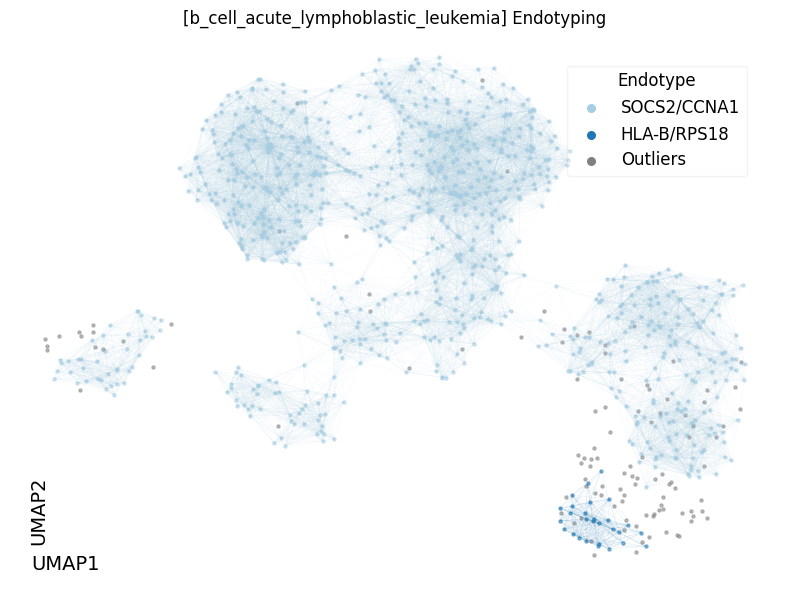

N components: 2 Filtration epsilon: 1.5


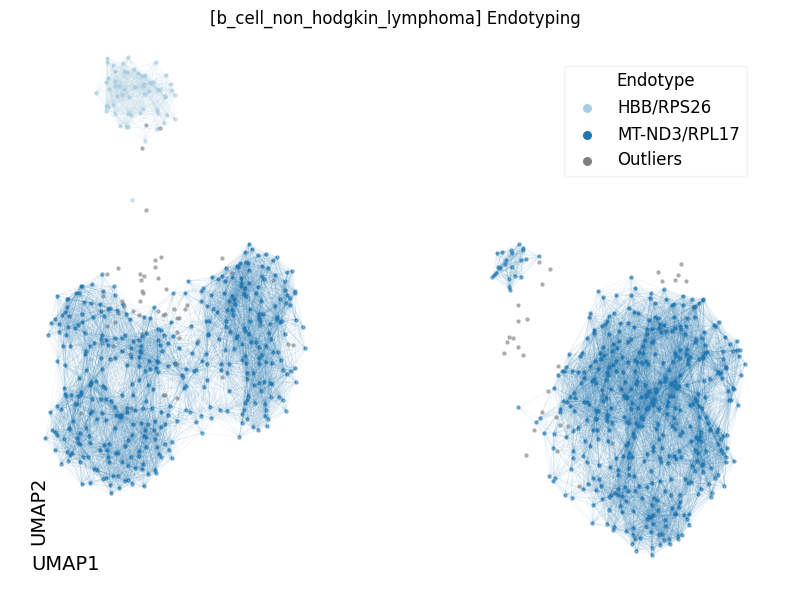

N components: 2 Filtration epsilon: 1.5


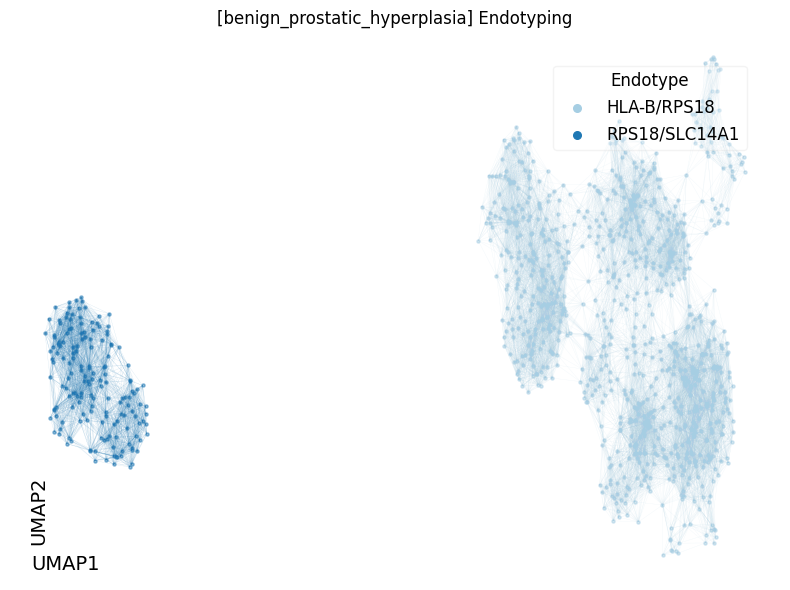

In [4]:
from matplotlib import cm
from scipy.spatial import distance
from matplotlib.collections import LineCollection
from scipy.spatial.distance import pdist, squareform
def plot_clusters_alpha(points=None, points2d=None, associated=None, epsilon=None, title='', markersize=10, linewidth=1, alphaline=0.2, alphamarker=0.4, save=False, override_components=None, cmap=None):
    # Identify connected components
    components = override_components
    distances = squareform(pdist(points, metric="euclidean"))
    adjacency = {i: set(np.where(distances[i] < epsilon)[0]) - {i} for i in range(len(points))}
    # Plot Vietoris-Rips Complex
    fig, ax = plt.subplots(figsize=(8,6), dpi=300 if SAVE else 100)
    cmap = sns.color_palette(cmap, len(components))
    print("N components:", len(components), "Filtration epsilon:", epsilon)
    for idx, comp in enumerate(components):
        color = cmap[idx]
        subcoords = points2d[comp]
        if associated is not None:
            genes = " - " + associated[idx]
        else: genes = ""
        ax.scatter(subcoords[:,0], subcoords[:,1], s=markersize, c=[color], alpha=alphamarker, label=f'{genes[3:]}')
        edges = [[points2d[i], points2d[j]] for i in comp for j in adjacency[i] if j in comp and i < j]
        lc = LineCollection(edges, colors=color, linewidths=linewidth, alpha=alphaline)
        ax.add_collection(lc)
    
    all_component_indices = np.concatenate(components)
    outlier_indices = np.setdiff1d(np.arange(len(points2d)), all_component_indices)
    if len(outlier_indices) > 0:
        ax.scatter(points2d[outlier_indices,0], points2d[outlier_indices,1], 
                   s=markersize, c='grey', alpha=0.5, label='Outliers')

    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([]); ax.set_yticks([])
    label = "UMAP"
    x_min, x_max = points2d[:, 0].min(), points2d[:, 0].max()
    y_min, y_max = points2d[:, 1].min(), points2d[:, 1].max()

    x_margin = 0.02 * (x_max - x_min)
    y_margin = 0.02 * (y_max - y_min)
    fontsize = 12
    fontweight='500'
    ax.text(x_min-x_margin, y_min, f'{label}1', ha='left', va='top', fontsize=fontsize+2, fontweight=fontweight)
    ax.text(x_min-1.1*x_margin, y_min+y_margin, f'{label}2', ha='left', va='bottom', rotation=90, fontsize=fontsize+2, fontweight=fontweight)
    ax.legend(
    loc='upper right',
    bbox_to_anchor=(1, 1),
    borderaxespad=2,
    fontsize=fontsize,
    frameon=True,
    facecolor='white',
    edgecolor='lightgrey',
    framealpha=0.25,
    title="Endotype",
    title_fontsize=fontsize
    #linewidth=2
    )     
    for legend_handle in ax.legend_.legendHandles:
        legend_handle.set_alpha(1)
        legend_handle.set_sizes([30])
    plt.title(title, fontsize=fontsize)
    plt.tight_layout()
    if SAVE: plt.savefig(f'disease-vector-plots/figure3/C_rips_complex-{title}.png', dpi=300, transparent=True)
    plt.show()

for d in df.columns[:3]:
    #visual_eps = [1.5] * 4 
    components, points, points2d, epsilon, associated_genes = df.loc["components", d], df.loc["points", d],  df.loc["umap", d], np.array(df.loc['h0', d]
                                                                                )[np.array(df.loc['h0_significance', d])].min(), df.loc['gene_tags', d]
    visual_eps = 1.5
    plot_clusters_alpha(points=np.array(points2d), epsilon=visual_eps, points2d=np.array(points2d), title=f'{d} Endotyping', 
                        markersize=5, linewidth=0.2, alphaline=0.2, alphamarker=0.5, override_components=components,
                          associated=associated_genes, cmap='Paired', )

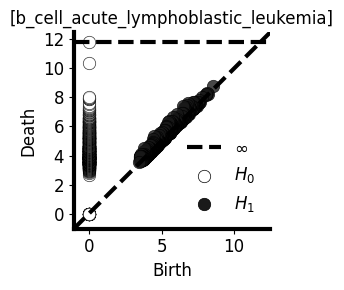

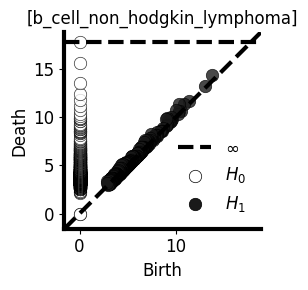

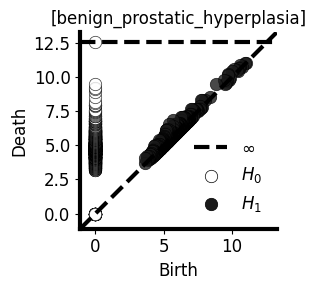

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def plot_diagrams(
    diagrams,
    plot_only=None,
    title=None,
    xy_range=None,
    labels=None,
    colormap="default",
    size=20,
    ax_color=np.array([0.0, 0.0, 0.0]),
    diagonal=True,
    lifetime=False,
    legend=True,
    show=False,
    ax=None,
    colors=None,
):
    ax = ax or plt.gca()
    plt.style.use(colormap)
    xlabel, ylabel = "Birth", "Death"
    if not isinstance(diagrams, list):
        diagrams = [diagrams]
    if labels is None:
        labels = ["$H_{{{}}}$".format(i) for i, _ in enumerate(diagrams)]
    if plot_only:
        diagrams = [diagrams[i] for i in plot_only]
        labels = [labels[i] for i in plot_only]
    if not isinstance(labels, list):
        labels = [labels] * len(diagrams)
    diagrams = [dgm.astype(np.float32, copy=True) for dgm in diagrams]
    concat_dgms = np.concatenate(diagrams).flatten()
    has_inf = np.any(np.isinf(concat_dgms))
    finite_dgms = concat_dgms[np.isfinite(concat_dgms)]
    if not xy_range:
        ax_min, ax_max = np.min(finite_dgms), np.max(finite_dgms)
        x_r = ax_max - ax_min
        buffer = 1 if xy_range == 0 else x_r / 5
        x_down, x_up = ax_min - buffer / 2, ax_max + buffer
        y_down, y_up = x_down, x_up
    else:
        x_down, x_up, y_down, y_up = xy_range
    yr = y_up - y_down
    if lifetime:
        diagonal = False
        y_down = -yr * 0.05
        y_up = y_down + yr
        ylabel = "Lifetime"
        for dgm in diagrams:
            dgm[:, 1] -= dgm[:, 0]
        ax.plot([x_down, x_up], [0, 0], c=ax_color)
    if diagonal:
        ax.plot([x_down, x_up], [x_down, x_up], "--", c=ax_color, lw=3)
    if has_inf:
        b_inf = y_down + yr * 0.95
        ax.plot([x_down, x_up], [b_inf, b_inf], "--", c="k", label=r"$\infty$", lw=3)
        for dgm in diagrams:
            dgm[np.isinf(dgm)] = b_inf
    for dgm, label, c in zip(diagrams, labels, colors):
        ax.scatter(dgm[:, 0], dgm[:, 1], size, label=label, color=c, alpha=0.8, linewidths=.5, edgecolor='k')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
    ax.set_xlim([x_down, x_up])
    ax.set_ylim([y_down, y_up])
    ax.set_aspect("equal", "box")
    for spine in ax.spines.values(): spine.set_linewidth(0)

    if title is not None:
        ax.set_title(title)
    if legend:
        ax.legend(loc="lower right")
    ax.legend(fontsize=16)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontsize(12)
        #tick_label.set_text(str(int(float(tick_label.get_text()))))

    ax.set_xlabel(ax.get_xlabel(), fontsize=12)
    ax.set_ylabel(ax.get_ylabel(), fontsize=12)
    [ax.spines[s].set_linewidth(0) for s in ['right','top']]
    [ax.spines[s].set_linewidth(3) for s in ['bottom','left']]

fontsize=12
size=80
colors = sns.color_palette("tab20c", 2)
colors = sns.color_palette("Paired", 2)
colors = [(1, 1, 1, 0), (.1, .1, .1, 0.8)]
for d in df.columns[:3]: 
    fig, axes = plt.subplots(1, 1, figsize=(4, 3), dpi=300 if SAVE else 100)
    plot_diagrams(df.loc["ripser", d], ax=axes, colors=colors, size=size)
    axes.set_title(f"{d}", fontsize=fontsize)
    axes.legend(frameon=False, fontsize=fontsize)
    axes.set_xlabel('Birth',fontsize=fontsize)
    axes.set_ylabel('Death',fontsize=fontsize)
    for legend_handle in axes.legend_.legendHandles:
        legend_handle.set_alpha(1)
    plt.tight_layout()
    if SAVE: plt.savefig(f'disease-vector-plots/figure3/C_persistence_diagrams_{d}.svg', dpi=300, transparent=True)
    plt.show()

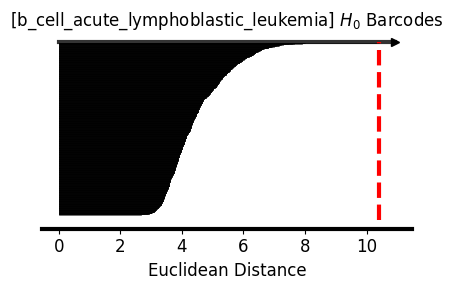

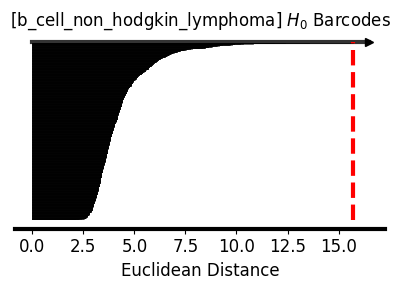

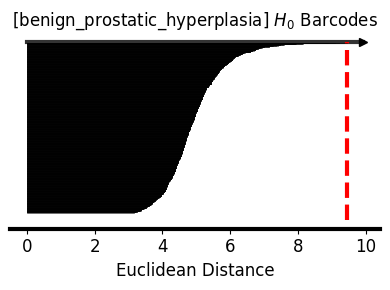

In [ ]:
import io
class Barcode:
    def __init__(self, diagrams, verbose=False):

        if not isinstance(diagrams, list):
            diagrams = [diagrams]

        self.diagrams = diagrams
        self._verbose = verbose
        self._dim = len(diagrams)

    def plot_barcode(self, figsize=None, show=True, export_png=False, dpi=100, **kwargs):
        if figsize is None:
            figsize = (6, 4)

        return self._plot_Hn(
            figsize=figsize,
            show=show,
            export_png=export_png,
            dpi=dpi,
            **kwargs
        )

    def _plot_Hn(self, *, figsize, show, export_png, dpi, **kwargs):
        out = []

        for dim, diagram in enumerate(self.diagrams):
            if dim > 0:continue
            fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=300 if SAVE else 100)

            self._plot_many_bars(dim, diagram, 0, [ax], **kwargs)
        return ax


    def _plot_many_bars(self, dim, diagram, idx, ax, **kwargs):
        number_of_bars = len(diagram)
        if self._verbose:
            print("Number of bars in dimension %d: %d" % (dim, number_of_bars))

        if number_of_bars > 0:
            births = np.vstack([(elem[0], i) for i, elem in enumerate(diagram)])
            deaths = np.vstack([(elem[1], i) for i, elem in enumerate(diagram)])

            inf_bars = np.where(np.isinf(deaths))[0]
            max_death = deaths[np.isfinite(deaths[:, 0]), 0].max()

            number_of_bars_fin = births.shape[0] - inf_bars.shape[0]
            number_of_bars_inf = inf_bars.shape[0]

            _ = [self._plot_a_bar(ax[idx], birth, deaths[i], max_death, **kwargs) for i, birth in enumerate(births)]

        # the line below is to plot a vertical red line showing the maximal finite bar length
        ax[idx].plot(
            [max_death, max_death],
            [0, number_of_bars - 1],
            c='r',
            linestyle='--',
            linewidth=3
        )

        title = "H%d barcode: %d finite, %d infinite" % (dim, number_of_bars_fin, number_of_bars_inf)
        ax[idx].set_title(title, fontsize=9)
        ax[idx].set_yticks([])

        for loc in ('right', 'left', 'top'):
            ax[idx].spines[loc].set_visible(False)
        ax[idx].spines['bottom'].set_linewidth(3)

    @staticmethod
    def _plot_a_bar(ax, birth, death, max_death, c='k', linestyle='-', linewidth=0.5):
        if np.isinf(death[0]):
            death[0] = 1.05 * max_death
            c='k'
            linewidth=3
            ax.plot(death[0],death[1],c=c,markersize=6,marker='>',)
        ax.plot( [birth[0], death[0]], [birth[1], death[1]],  c=c, alpha=0.8, linestyle=linestyle, linewidth=linewidth)

for d in df.columns[:3]: 
    bc = Barcode(df.loc["ripser", d])
    ax = bc.plot_barcode( figsize=(4,3))
    ax.set_title(f'{d} $H_0$ Barcodes', fontsize=12)
    ax.set_xlabel('Euclidean Distance', fontsize=12)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontsize(12)
    plt.tight_layout()
    if SAVE: plt.savefig(f'disease-vector-plots/figure3/C_barcodes_{d}.png', dpi=300, transparent=True)